# Exp 5: Text Backbone Selection — ResNet50 Global + DistilBERT vs RoBERTa + Concat + MLP

**Goal:** Fix best image representation (from Exp 4) and compare DistilBERT vs RoBERTa.

**DistilBERT result is free** — reused from Exp 4 global result. Only RoBERTa is retrained.

**Hyperparameters:** Auto-loaded from `results/tuning/exp5_roberta_best_params.json`.

**Note:** Requires `results/exp4.json` — run Exp 4 first.

In [1]:
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import json, os, copy
import warnings

warnings.filterwarnings('ignore')

ROOT   = Path('..').resolve()
DEVICE = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}  |  Root: {ROOT}')

Device: mps  |  Root: /Users/shrutisivakumar/Library/CloudStorage/OneDrive-Personal/College Stuff/Sem 6/Projects/NLP/Facebook-Hateful-Memes-Challenge-2020


## 1. Load Exp 4 Context (DistilBERT baseline — free)

In [2]:
assert (ROOT / 'results/exp4.json').exists(), 'Run exp4 first!'
exp4 = json.load(open(ROOT / 'results/exp4.json'))

BEST_IMG_KEY    = exp4['best_image_key']             # e.g. 'resnet50' or 'resnet50_yolo'
IMG_DIM         = exp4['img_dim']
best_repr       = exp4['best_image_representation']  # 'global' or 'yolo'
DISTILBERT_AUC  = exp4['results'][best_repr]['dev_auc_roc']
DISTILBERT_ACC  = exp4['results'][best_repr]['dev_accuracy']

print(f'Best image key     : {BEST_IMG_KEY} (dim={IMG_DIM})')
print(f'DistilBERT AUC     : {DISTILBERT_AUC:.4f}  [reused from Exp 4 — no retraining]')

Best image key     : vit_yolo (dim=768)
DistilBERT AUC     : 0.6636  [reused from Exp 4 — no retraining]


## 2. Load Embeddings — Best Image + RoBERTa

In [3]:
IMG_DIR  = ROOT / 'artifacts/embeddings/image'
TEXT_DIR = ROOT / 'artifacts/embeddings/text'

Xi_tr = np.load(IMG_DIR  / f'train_{BEST_IMG_KEY}.npy').astype(np.float32)
Xt_tr = np.load(TEXT_DIR / 'train_roberta.npy').astype(np.float32)
y_tr  = np.load(IMG_DIR  / 'train_labels.npy')
Xi_dv = np.load(IMG_DIR  / f'dev_{BEST_IMG_KEY}.npy').astype(np.float32)
Xt_dv = np.load(TEXT_DIR / 'dev_roberta.npy').astype(np.float32)
y_dv  = np.load(IMG_DIR  / 'dev_labels.npy')

sci = StandardScaler().fit(Xi_tr)
sct = StandardScaler().fit(Xt_tr)
Xi_tr, Xi_dv = sci.transform(Xi_tr), sci.transform(Xi_dv)
Xt_tr, Xt_dv = sct.transform(Xt_tr), sct.transform(Xt_dv)

pos_weight = torch.tensor([(y_tr==0).sum() / (y_tr==1).sum()],
                           dtype=torch.float32).to(DEVICE)
print(f'img={Xi_tr.shape}, text(RoBERTa)={Xt_tr.shape}')
print(f'pos_weight: {pos_weight.item():.3f}')

img=(8500, 768), text(RoBERTa)=(8500, 768)
pos_weight: 1.787


## 3. Load Tuned Hyperparameters

In [4]:
tuning_path = ROOT / 'results/tuning/exp5_roberta_best_params.json'
if tuning_path.exists():
    p = json.load(open(tuning_path))['params']
    print(f'Loaded tuned params: {p}')
else:
    p = {'proj_dim': 256, 'hidden1': 128, 'hidden2': 32,
         'dropout_proj': 0.3, 'dropout1': 0.3, 'dropout2': 0.2,
         'lr': 3e-4, 'weight_decay': 1e-4}
    print(f'Tuning params not found — using defaults: {p}')

Loaded tuned params: {'proj_dim': 512, 'hidden1': 128, 'hidden2': 64, 'dropout_proj': 0.34990176943796875, 'dropout1': 0.3844441061352564, 'dropout2': 0.34419811167334946, 'lr': 0.005634783190720708, 'weight_decay': 0.0001863574604726976}


## 4. DataLoaders

In [5]:
BATCH_SIZE = 64

def make_loader(Xi, Xt, y, shuffle=False):
    ds = TensorDataset(torch.tensor(Xi, dtype=torch.float32),
                       torch.tensor(Xt, dtype=torch.float32),
                       torch.tensor(y,  dtype=torch.float32))
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)

train_loader = make_loader(Xi_tr, Xt_tr, y_tr, shuffle=True)
dev_loader   = make_loader(Xi_dv, Xt_dv, y_dv)
print(f'Batches — Train: {len(train_loader)}, Dev: {len(dev_loader)}')

Batches — Train: 133, Dev: 8


## 5. Model

In [6]:
class ProjectionFusionMLP(nn.Module):
    def __init__(self, img_dim, text_dim=768, proj_dim=256,
                 d_proj=0.3, h1=128, h2=32, d1=0.3, d2=0.2):
        super().__init__()
        self.img_proj  = nn.Sequential(nn.Linear(img_dim,  proj_dim), nn.GELU(), nn.Dropout(d_proj))
        self.text_proj = nn.Sequential(nn.Linear(text_dim, proj_dim), nn.GELU(), nn.Dropout(d_proj))
        self.classifier = nn.Sequential(
            nn.Linear(proj_dim * 2, h1), nn.LayerNorm(h1), nn.GELU(), nn.Dropout(d1),
            nn.Linear(h1, h2),           nn.LayerNorm(h2), nn.GELU(), nn.Dropout(d2),
            nn.Linear(h2, 1)
        )
    def forward(self, x_img, x_text):
        return self.classifier(
            torch.cat([self.img_proj(x_img), self.text_proj(x_text)], dim=-1)
        ).squeeze(-1)

model = ProjectionFusionMLP(
    img_dim=IMG_DIM, text_dim=768,
    proj_dim=p['proj_dim'], d_proj=p['dropout_proj'],
    h1=p['hidden1'], h2=p['hidden2'],
    d1=p['dropout1'], d2=p['dropout2']
).to(DEVICE)

print(f'Trainable params: {sum(par.numel() for par in model.parameters() if par.requires_grad):,}')

Trainable params: 927,361


## 6. Training Setup

In [7]:
EPOCHS       = 50
LR           = p['lr']
WEIGHT_DECAY = p['weight_decay']
PATIENCE     = 10

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
print(f'LR: {LR} | WD: {WEIGHT_DECAY} | Epochs: {EPOCHS} | Patience: {PATIENCE}')

LR: 0.005634783190720708 | WD: 0.0001863574604726976 | Epochs: 50 | Patience: 10


## 7. Train — RoBERTa

In [8]:
def run_epoch(loader, model, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, all_probs, all_labels = 0, [], []
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for x_img, x_text, y in loader:
            x_img, x_text, y = x_img.to(DEVICE), x_text.to(DEVICE), y.to(DEVICE)
            logits = model(x_img, x_text)
            loss   = criterion(logits, y)
            if is_train:
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item() * len(y)
            all_probs.extend(torch.sigmoid(logits).detach().cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    auc = roc_auc_score(all_labels, all_probs)
    acc = accuracy_score(all_labels, (np.array(all_probs) >= 0.5).astype(int))
    return total_loss / len(all_labels), auc, acc, np.array(all_probs), np.array(all_labels)


history = {'train_loss': [], 'dev_loss': [], 'train_auc': [], 'dev_auc': []}
best_dev_auc, best_state, patience_ctr = 0.0, None, 0

print('Training: ResNet50 + RoBERTa + Proj-Concat + MLP')
print('=' * 55)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_auc, tr_acc, _, _ = run_epoch(train_loader, model, criterion, optimizer)
    dv_loss, dv_auc, dv_acc, _, _ = run_epoch(dev_loader,   model, criterion)
    scheduler.step()

    history['train_loss'].append(tr_loss); history['dev_loss'].append(dv_loss)
    history['train_auc'].append(tr_auc);   history['dev_auc'].append(dv_auc)

    if dv_auc > best_dev_auc:
        best_dev_auc = dv_auc; best_state = copy.deepcopy(model.state_dict())
        patience_ctr = 0; flag = '  <- best'
    else:
        patience_ctr += 1; flag = f'  (patience {patience_ctr}/{PATIENCE})'

    print(f'Ep {epoch:02d} | Tr Loss {tr_loss:.4f} AUC {tr_auc:.4f} | '
          f'Dev Loss {dv_loss:.4f} AUC {dv_auc:.4f} Acc {dv_acc:.4f}{flag}')

    if patience_ctr >= PATIENCE:
        print(f'Early stopping at epoch {epoch}'); break

print(f'\nBest Dev AUC: {best_dev_auc:.4f}')
model.load_state_dict(best_state)

Training: ResNet50 + RoBERTa + Proj-Concat + MLP
Ep 01 | Tr Loss 0.8152 AUC 0.6928 | Dev Loss 1.0388 AUC 0.6010 Acc 0.5680  <- best
Ep 02 | Tr Loss 0.7419 AUC 0.7665 | Dev Loss 1.1519 AUC 0.6227 Acc 0.5800  <- best
Ep 03 | Tr Loss 0.6849 AUC 0.8086 | Dev Loss 1.1449 AUC 0.6338 Acc 0.5920  <- best
Ep 04 | Tr Loss 0.6434 AUC 0.8334 | Dev Loss 1.0624 AUC 0.6437 Acc 0.5880  <- best
Ep 05 | Tr Loss 0.5927 AUC 0.8615 | Dev Loss 1.1729 AUC 0.6274 Acc 0.6060  (patience 1/10)
Ep 06 | Tr Loss 0.5533 AUC 0.8801 | Dev Loss 1.3315 AUC 0.6386 Acc 0.6040  (patience 2/10)
Ep 07 | Tr Loss 0.5184 AUC 0.8962 | Dev Loss 1.2435 AUC 0.6278 Acc 0.6020  (patience 3/10)
Ep 08 | Tr Loss 0.4786 AUC 0.9126 | Dev Loss 1.3677 AUC 0.6373 Acc 0.5760  (patience 4/10)
Ep 09 | Tr Loss 0.4529 AUC 0.9223 | Dev Loss 1.3567 AUC 0.6274 Acc 0.5760  (patience 5/10)
Ep 10 | Tr Loss 0.4127 AUC 0.9360 | Dev Loss 1.4597 AUC 0.6487 Acc 0.5880  <- best
Ep 11 | Tr Loss 0.3763 AUC 0.9472 | Dev Loss 1.5188 AUC 0.6420 Acc 0.5860  (patie

<All keys matched successfully>

## 8. Training Curves

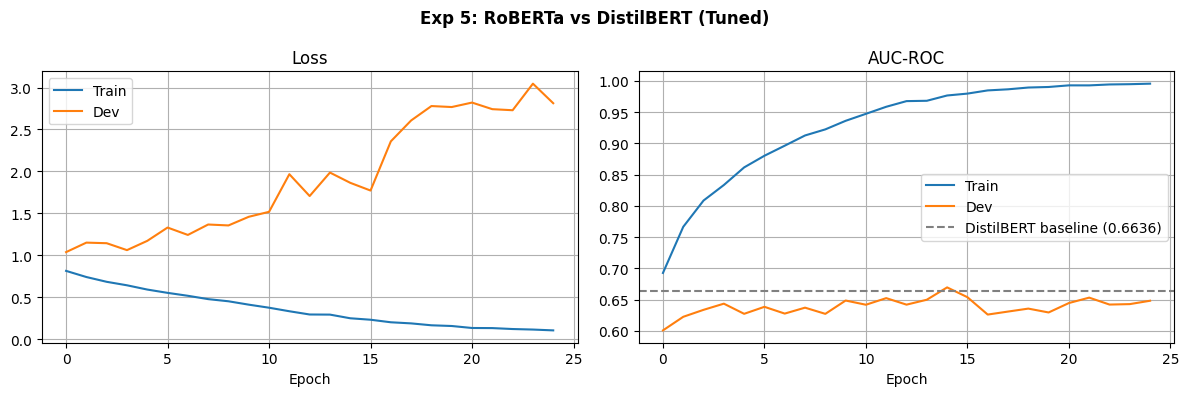

In [9]:
os.makedirs(ROOT / 'outputs', exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['dev_loss'],   label='Dev')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True)
axes[1].plot(history['train_auc'], label='Train')
axes[1].plot(history['dev_auc'],   label='Dev')
axes[1].axhline(DISTILBERT_AUC, color='gray', linestyle='--',
                label=f'DistilBERT baseline ({DISTILBERT_AUC:.4f})')
axes[1].set_title('AUC-ROC'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True)
plt.suptitle('Exp 5: RoBERTa vs DistilBERT (Tuned)', fontweight='bold')
plt.tight_layout()
plt.savefig(ROOT / 'outputs/05_training_curves.png', dpi=150)
plt.show()

## 9. Final Comparison — DistilBERT vs RoBERTa

In [10]:
_, roberta_auc, roberta_acc, roberta_probs, roberta_true = run_epoch(dev_loader, model, criterion)
roberta_preds = (roberta_probs >= 0.5).astype(int)

print('=' * 60)
print('EXP 5 — Text Backbone Comparison | Dev Set')
print('=' * 60)
print(f'  DistilBERT (Exp 4) : AUC = {DISTILBERT_AUC:.4f}  Acc = {DISTILBERT_ACC:.4f}  [reused]')
print(f'  RoBERTa    (Exp 5) : AUC = {roberta_auc:.4f}  Acc = {roberta_acc:.4f}')
delta = roberta_auc - DISTILBERT_AUC
print(f'  Delta              : {delta:+.4f}')

best_text = 'roberta' if roberta_auc >= DISTILBERT_AUC else 'distilbert'
best_text_auc = max(roberta_auc, DISTILBERT_AUC)
print(f'\n-> Best text backbone: {best_text.upper()} (AUC = {best_text_auc:.4f})')

print(f'\nClassification Report — {BEST_IMG_KEY.upper()} + RoBERTa:')
print(classification_report(roberta_true, roberta_preds, target_names=['Not Hateful', 'Hateful']))

EXP 5 — Text Backbone Comparison | Dev Set
  DistilBERT (Exp 4) : AUC = 0.6636  Acc = 0.6260  [reused]
  RoBERTa    (Exp 5) : AUC = 0.6697  Acc = 0.5940
  Delta              : +0.0061

-> Best text backbone: ROBERTA (AUC = 0.6697)

Classification Report — VIT_YOLO + RoBERTa:
              precision    recall  f1-score   support

 Not Hateful       0.57      0.78      0.66       250
     Hateful       0.65      0.41      0.50       250

    accuracy                           0.59       500
   macro avg       0.61      0.59      0.58       500
weighted avg       0.61      0.59      0.58       500



## 10. Save Model & Results

In [11]:
os.makedirs(ROOT / 'models', exist_ok=True)
os.makedirs(ROOT / 'results', exist_ok=True)

torch.save(best_state, ROOT / f'models/05_{BEST_IMG_KEY}_roberta_concat_mlp.pt')

exp5_out = {
    'experiment': '05_TextBackboneSelection',
    'image_backbone': BEST_IMG_KEY, 'img_dim': IMG_DIM,
    'pipeline': 'img_proj + text_proj -> concat -> MLP',
    'results': {
        'distilbert': {'dev_auc_roc': DISTILBERT_AUC, 'dev_accuracy': DISTILBERT_ACC,
                       'note': 'reused from exp4'},
        'roberta':    {'dev_auc_roc': round(float(roberta_auc), 4),
                       'dev_accuracy': round(float(roberta_acc), 4)}
    },
    'best_text_backbone': best_text,
    'best_text_dim': 768
}
with open(ROOT / 'results/exp5.json', 'w') as f:
    json.dump(exp5_out, f, indent=2)

print(f'Model   → models/05_{BEST_IMG_KEY}_roberta_concat_mlp.pt')
print('Results → results/exp5.json')
print(json.dumps(exp5_out, indent=2))

Model   → models/05_vit_yolo_roberta_concat_mlp.pt
Results → results/exp5.json
{
  "experiment": "05_TextBackboneSelection",
  "image_backbone": "vit_yolo",
  "img_dim": 768,
  "pipeline": "img_proj + text_proj -> concat -> MLP",
  "results": {
    "distilbert": {
      "dev_auc_roc": 0.6636,
      "dev_accuracy": 0.626,
      "note": "reused from exp4"
    },
    "roberta": {
      "dev_auc_roc": 0.6697,
      "dev_accuracy": 0.594
    }
  },
  "best_text_backbone": "roberta",
  "best_text_dim": 768
}
